<a href="https://colab.research.google.com/github/Gonza03s/intro-analisis-de-datos/blob/master/actividad_integradora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 18. Actividad integradora

Trabajemos con el siguiente conjunto de datos. Es intencionalmente pequeño y tiene "trampas" (un cliente de 65 años y un ingreso de 5000, muy alejados del resto) para que se noten los efectos que venimos estudiando.

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "edad": [20, 21, 22, 22, 23, 24, 25, 26, 27, 65],
    "ingreso": [500, 520, 550, 580, 600, 620, 650, 680, 700, 5000],
    "compras": [2, 3, 3, 4, 4, 5, 5, 6, 7, 15],
    "ciudad": [
        "La Plata", "La Plata", "La Plata", "CABA", "CABA",
        "CABA", "La Plata", "Rosario", "Rosario", "CABA"
    ]
})

df

,edad,ingreso,compras,ciudad
0,20,500,2,La Plata
1,21,520,3,La Plata
2,22,550,3,La Plata
3,22,580,4,CABA
4,23,600,4,CABA
5,24,620,5,CABA
6,25,650,5,La Plata
7,26,680,6,Rosario
8,27,700,7,Rosario
9,65,5000,15,CABA


La idea de esta actividad es recorrer los tres niveles de análisis en orden, y en cada uno entender **para qué sirve** antes de calcularlo. No alcanza con saber qué método aplicar: hay que entender qué pregunta responde y qué decisión ayuda a tomar.

## Análisis univariado: entender una variable por separado

**¿Para qué sirve este paso?** Antes de comparar variables entre sí, necesitamos conocer cada una individualmente. Si no sabemos cómo se comporta `edad` por sí sola, cualquier conclusión que saquemos después sobre su relación con otras variables va a estar mal fundada. Es el paso de "conocer el terreno" antes de buscar relaciones.

Empezamos con:

In [ ]:
df["edad"].describe()

,edad
count,10.000000
mean,27.500000
std,13.360389
min,20.000000
25%,22.000000
50%,23.500000
75%,25.750000
max,65.000000


- **La media y la mediana** nos dan dos formas distintas de estimar "el centro" de las edades. Si las calculás vas a ver que la media da bastante más alta que la mediana — eso ya es una señal de que algo tira la media hacia arriba (spoiler: el cliente de 65 años). Comparar ambas es útil justamente para detectar esta clase de distorsión sin todavía mirar el dato en detalle.
- **El desvío estándar** nos dice qué tan dispersos están los valores respecto a esa media. Un desvío grande en relación con la media es una alerta de que el grupo no es tan homogéneo como parece.
- **Q1 y Q3** nos permiten calcular el IQR y, con él, poner un límite objetivo (no "a ojo") para decidir qué valores son candidatos a outlier.
- Con esos tres elementos (media/mediana, desvío, cuartiles) ya podemos responder si **hay posibles valores atípicos**: calculá `limite_superior = q3 + 1.5*iqr` y fijate si el cliente de 65 años queda fuera de ese límite. Este paso importa porque, si más adelante calculamos una correlación sin darnos cuenta de que ese dato está ahí, el resultado puede estar completamente distorsionado por un solo cliente.

In [ ]:
# rango
df["edad"].max() - df["edad"].min()

45

In [ ]:
q1 = df["edad"].quantile(0.25)
q1

np.float64(22.0)

In [ ]:
q1 = df["edad"].quantile(0.25)
q2 = df["edad"].quantile(0.50)
q3 = df["edad"].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Límite superior:", limite_superior)
print("¿Hay edades por encima del límite?")
df[df["edad"] > limite_superior]

Q1: 22.0
Q3: 25.75
IQR: 3.75
Límite superior: 31.375
¿Hay edades por encima del límite?


,edad,ingreso,compras,ciudad
9,65,5000,15,CABA


## Análisis bivariado: buscar relaciones entre dos variables

**¿Para qué sirve este paso?** Una vez que entendemos cada variable por separado, la pregunta natural es si se mueven juntas. Esto es clave, por ejemplo, para decisiones de negocio: si edad e ingreso están relacionados, una empresa podría segmentar campañas por franja etaria en lugar de tratar a todos los clientes igual.

ciudad
CABA        1700.0
La Plata     555.0
Rosario      690.0
Name: ingreso, dtype: float64
ciudad
CABA        610.0
La Plata    535.0
Rosario     690.0
Name: ingreso, dtype: float64


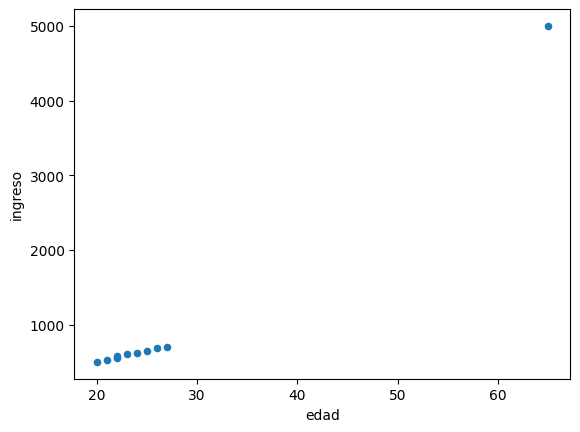

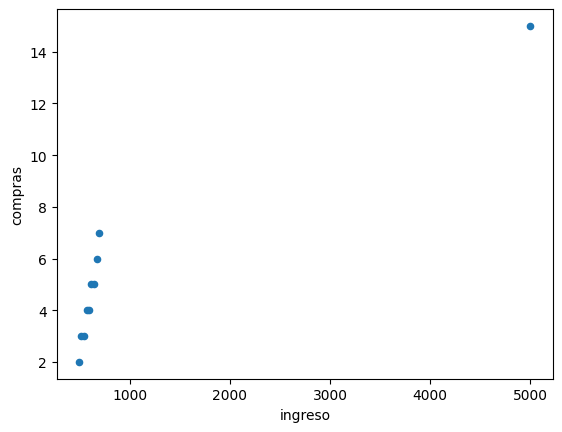

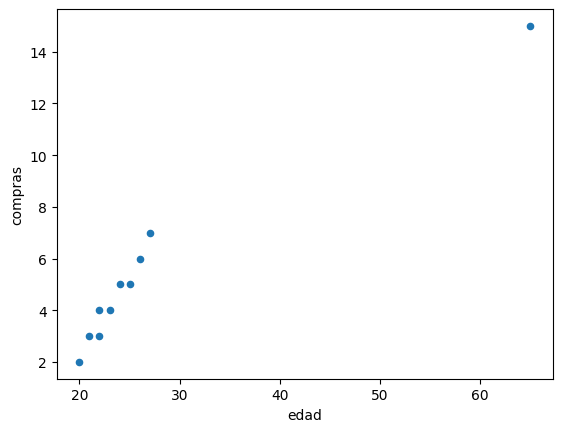

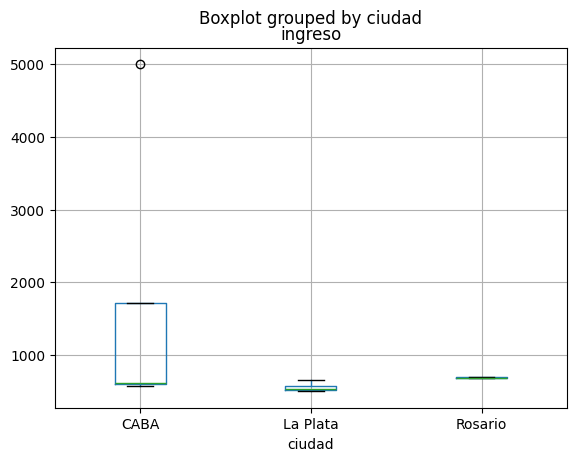

In [ ]:
# Edad vs. Ingreso
# nos preguntamos, ¿A medida que aumenta la edad, aumenta también el ingreso?
df.plot(x="edad", y="ingreso", kind="scatter")

# Compras vs. Ingreso
# ¿Los clientes que tienen mayores ingresos realizan más compras?
df.plot.scatter(x="ingreso", y="compras")

# Edad vs. Compras
# ¿Existe una relación entre la edad y la cantidad de compras?
df.plot.scatter(x="edad", y="compras")

# Ciudad vs. Ingreso (categórica + numérica)
# ¿El ingreso se distribuye de la misma manera entre las distintas ciudades?
df.boxplot(column="ingreso", by="ciudad")
# Obviamente podriamos hacer tambien (sin grafico) para comparar medias y medianas.
print(df.groupby("ciudad")["ingreso"].mean())
print(df.groupby("ciudad")["ingreso"].median())


In [ ]:
print(df["edad"].corr(df["ingreso"])) # Edad vs. Ingreso
print(df["ingreso"].corr(df["compras"])) # Compras vs. Ingreso
print(df["edad"].corr(df["compras"])) # Edad vs. Compras

0.9928218243187513
0.9322493907114316
0.9674448528034966


- El **scatter plot** es el primer paso porque es visual: antes de reducir la relación a un solo número (la correlación), conviene *ver* la forma de la nube de puntos. A veces una relación es clara a simple vista aunque el número de correlación no la capture bien (por ejemplo, si la relación no es lineal).
- La **correlación** cuantifica esa relación en un número entre -1 y 1, lo que permite comparar la fuerza de distintas relaciones entre sí (algo que "a ojo" en un gráfico es más difícil de hacer con precisión).
- Acá es donde entra el outlier que detectamos antes: calculá la correlación con y sin el cliente de 65 años/5000 de ingreso, y vas a ver que el resultado cambia bastante. Esto muestra en la práctica por qué detectar outliers en el paso univariado no es un trámite: afecta directamente las conclusiones bivariadas.

In [ ]:
# Correlación sin el outlier (cliente de 65 años / ingreso 5000)
df_sin_outlier = df[df["edad"] <= limite_superior]

print("Correlación con outlier:", df["edad"].corr(df["ingreso"]))
print("Correlación sin outlier:", df_sin_outlier["edad"].corr(df_sin_outlier["ingreso"]))

Correlación con outlier: 0.9928218243187513
Correlación sin outlier: 0.989850757388692


Por último, aunque encuentres una correlación alta, recordá que **no podés concluir causalidad** solo con este número: correlación alta no significa que la edad "cause" el ingreso, solo que se mueven juntos en estos datos.

## Análisis multivariado: ver cómo interactúan varias variables a la vez

**¿Para qué sirve este paso?** El análisis bivariado compara de a dos variables, pero en la realidad los fenómenos casi nunca dependen de una sola causa. Incorporar una tercera variable (o una cuarta) permite detectar patrones que quedan ocultos si miramos de a pares — por ejemplo, una relación que es fuerte en un grupo pero no en otro.

Con `edad`, `ingreso` y `compras` en conjunto:

- Preguntarse **si los clientes con mayores ingresos compran más** es un análisis bivariado (ingreso vs. compras) — pero al incorporar la edad como tercera variable podemos ver si esa relación es igual de fuerte en todas las franjas etarias, o si en realidad depende del grupo de edad.

In [ ]:
# Matriz de correlacion de Pearson
# La correlación de Pearson es una medida estadística que indica
# qué tan fuerte y en qué dirección es la relación lineal entre
# dos variables numéricas.
# El resultado está entre -1 y 1:
# | Correlación | Interpretación                    |
# | ----------: | --------------------------------- |
# |       **1** | Relación lineal positiva perfecta |
# |       **0** | No hay relación lineal            |
# |      **-1** | Relación lineal negativa perfecta |

df[["edad", "ingreso", "compras"]].corr()

,edad,ingreso,compras
edad,1.000000,0.992822,0.967445
ingreso,0.992822,1.000000,0.932249
compras,0.967445,0.932249,1.000000


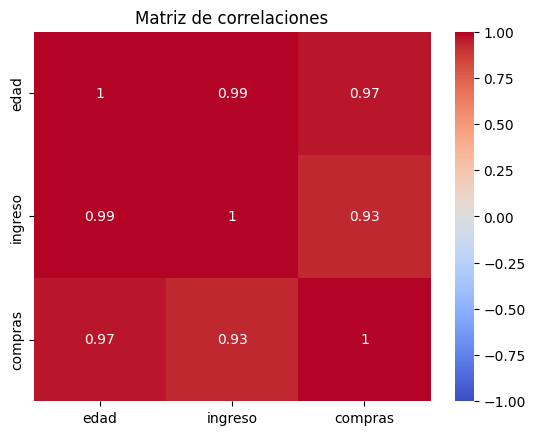

In [ ]:
# Con Pandas + Seaborn + Matplotlib
import seaborn as sns
import matplotlib.pyplot as plt

correlaciones = df[["edad", "ingreso", "compras"]].corr()

sns.heatmap(
    correlaciones,
    annot=True, # Hace que aparezca el valor numérico dentro de cada celda.
    cmap="coolwarm",
    vmin=-1, # Indica cuál es el valor mínimo de la escala de colores.
    vmax=1 # Indica cuál es el valor máximo de la escala de colores.
)

plt.title("Matriz de correlaciones")
plt.show()

# Hay 2 caracterisitcas importantes a señalar:
# La diagonal siempre es 1, porque una variable está perfectamente correlacionada consigo misma.
# La matriz es simétrica: edad → ingreso da lo mismo que ingreso → edad.

- Buscar **algún cliente que se comporte distinto al resto** ya no es solo detectar un outlier en una variable aislada, sino identificar una combinación inusual de varias variables a la vez (por ejemplo, alguien con ingreso alto pero pocas compras, algo que no se nota mirando cada variable por separado).

In [ ]:
df.sort_values("ingreso", ascending=False)

,edad,ingreso,compras,ciudad
9,65,5000,15,CABA
8,27,700,7,Rosario
7,26,680,6,Rosario
6,25,650,5,La Plata
5,24,620,5,CABA
4,23,600,4,CABA
3,22,580,4,CABA
2,22,550,3,La Plata
1,21,520,3,La Plata
0,20,500,2,La Plata


- Preguntarse **qué aportaría incorporar `ciudad`** apunta a algo importante: `ciudad` es categórica, así que no se combina con las demás variables de la misma forma que dos numéricas. Agregarla nos permitiría, por ejemplo, comparar si el patrón ingreso-compras es distinto en La Plata que en CABA — es decir, usar una variable categórica para **segmentar** el análisis numérico en subgrupos, en vez de mirar todo el dataset como un bloque único.

In [ ]:
df.groupby("ciudad")[["edad", "ingreso", "compras"]].mean()

,edad,ingreso,compras
ciudad,,,
CABA,33.5,1700.0,7.00
La Plata,22.0,555.0,3.25
Rosario,26.5,690.0,6.50


## Por qué importa este orden

El objetivo de esta actividad no es aplicar técnicas avanzadas, sino practicar una forma de pensar: primero conocer cada variable, después buscar relaciones de a pares, y recién ahí incorporar más variables para ver interacciones más complejas. Saltearse el primer paso (por ejemplo, calcular una correlación sin antes haber revisado outliers) es una de las causas más comunes de conclusiones erróneas en análisis de datos reales.